In [ ]:
img_path = "/kaggle/input/grocery/pepsi1.jpg"

In [ ]:
!rm -rf /root/.cache/torch/hub/isl-org_ZoeDepth_main
!rm -rf /root/.cache/torch/hub/checkpoints/ZoeD*


In [ ]:
!pip install -q timm==0.6.13 einops


In [3]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

zoe = torch.hub.load(
    "isl-org/ZoeDepth",
    "ZoeD_NK",
    pretrained=True,
    trust_repo=True,
    force_reload=True
)

zoe = zoe.to(device).eval()


Downloading: "https://github.com/isl-org/ZoeDepth/zipball/main" to /root/.cache/torch/hub/main.zip


img_size [384, 512]


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This ma

Params passed to Resize transform:
	width:  512
	height:  384
	resize_target:  True
	keep_aspect_ratio:  True
	ensure_multiple_of:  32
	resize_method:  minimal
Using pretrained resource url::https://github.com/isl-org/ZoeDepth/releases/download/v1.0/ZoeD_M12_NK.pt


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Loaded successfully


In [ ]:
!pip install "numpy<2.0"


In [1]:
import numpy as np
print(np.__version__)


1.26.4


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch


In [4]:
# Image path (any image, including YOLO dataset image)
image_path = "/kaggle/input/grocery/pepsi1.jpg"

# Read with OpenCV
img_bgr = cv2.imread(image_path)
assert img_bgr is not None, "Image not found!"

# Convert BGR → RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


In [7]:
from ultralytics import YOLO

yolo_model = YOLO("/kaggle/input/best1/pytorch/default/1/best (1).pt")
print("YOLO model loaded")


YOLO model loaded


In [8]:
import cv2

image_path = "//kaggle/input/grocery/pepsi1.jpg"

img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(img_rgb.shape)

(4080, 3072, 3)



image 1/1 //kaggle/input/grocery/pepsi1.jpg: 640x512 1 Dried Fruit, 3 Stationerys, 46.3ms
Speed: 34.7ms preprocess, 46.3ms inference, 23.2ms postprocess per image at shape (1, 3, 640, 512)


(-0.5, 3071.5, 4079.5, -0.5)

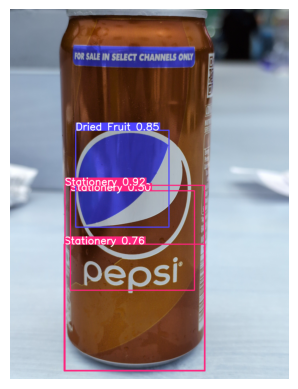

In [9]:
results = yolo_model(image_path, conf=0.4)
r = results[0]

# Draw detections
annotated = r.plot()
plt.imshow(annotated)
plt.axis("off")


(-0.5, 3071.5, 4079.5, -0.5)

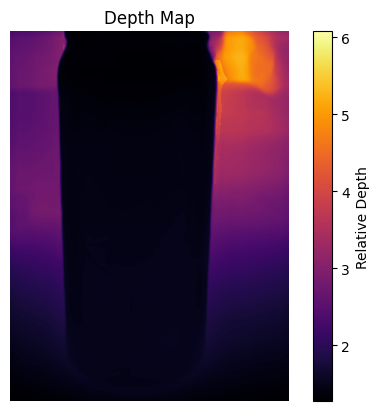

In [10]:
from PIL import Image

img_pil = Image.fromarray(img_rgb)

with torch.no_grad():
    depth = zoe.infer_pil(img_pil)

# ZoeDepth already returns NumPy
depth_map = depth.squeeze()

plt.imshow(depth_map, cmap="inferno")
plt.colorbar(label="Relative Depth")
plt.title("Depth Map")
plt.axis("off")


In [11]:
h, w = depth_map.shape

for box in r.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    # Clamp bounds
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)

    region_depth = depth_map[y1:y2, x1:x2]

    if region_depth.size == 0:
        continue

    avg_depth = float(region_depth.mean())

    cls_id = int(box.cls[0])
    label = r.names[cls_id]
    conf = float(box.conf[0])

    print(f"{label} ({conf:.2f}) → depth ≈ {avg_depth:.2f} meters")


Stationery (0.92) → depth ≈ 1.49 meters
Dried Fruit (0.85) → depth ≈ 1.44 meters
Stationery (0.76) → depth ≈ 1.50 meters
Stationery (0.50) → depth ≈ 1.48 meters


(-0.5, 3071.5, 4079.5, -0.5)

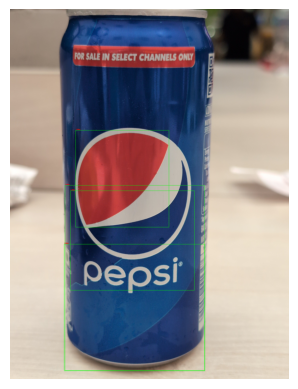

In [12]:
vis = img_rgb.copy()

for box in r.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    region_depth = depth_map[y1:y2, x1:x2]

    if region_depth.size == 0:
        continue

    depth_val = region_depth.mean()
    cv2.rectangle(vis, (x1,y1), (x2,y2), (0,255,0), 2)
    cv2.putText(
        vis,
        f"{depth_val:.2f}m",
        (x1, y1-5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255,0,0),
        2
    )

plt.imshow(vis)
plt.axis("off")
